# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 2 (Часть 2): GCN

### Оценивание и штрафы
Всего заданий: **5**, максимальная оценка — **6 баллов (+2.0 бонус)**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 15.03.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQ2ODc0NzExMTI5/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на основе графовых нейросетей для обучения эмбеддингов на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch_geometric

## Структура датасета

Датасет можете скачать по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link)

Датасет состоит из 6 основных файлов. Все данные представлены в текстовом формате, где колонки разделены символом табуляции `\t`.

### 1. Оценки пользователей
В этих файлах содержатся оценки фильмов пользователей
-  **Файлы:** `ydata-ymovies-user-movie-ratings-train-v1_0` и `ydata-ymovies-user-movie-ratings-test-v1_0`
- **Поля:**
  * User ID
  * Movie ID
  * Rating_13: от 1 (F) до 13 (A+)
  * Rating_5: упрощенная шкала от 1 до 5



### 2. Демография пользователей
Информация про аудиторию

- **Файл:** `ydata-ymovies-user-demographics-v1_0`
- **Поля:**
  * User ID
  * Year of birth
  * Sex (`m`/`f`)

### 3. Описание фильмов
Метаданные фильмов
* **Файл:** `ydata-ymovies-movie-content-descr-v1_0`
* **Что внутри:** Название, синопсис, жанры, режиссеры, актеры, количество наград, средняя оценка критиков и даже ссылки на постеры.
* **Важно:** Если данных нет, стоит заглушка `\N`. Если в поле несколько значений (например, список актеров), они разделены символом `|`.

### 4. Списки соответствия
Файлы `mapping-to-movielens` и `mapping-to-eachmovie` позволяют связать ID фильмов Yahoo с другими популярными датасетами (MovieLens и EachMovie). Это полезно, если вы хотите объединить данные из разных источников


### GCN

В этой части мы будем строить эмбеддинги пользователей и фильмов с помощью графа Лапласиана, чтобы потом на этих эмбеддингах обучать supervised модель, которая уже будет рекомендовать фильмы

**Задание 0 (1 балл):** Как и в первой части ДЗ-2, вам необходимо построить двудольный граф взаимодействий `user-item` (берем оценки $\geqslant 4$ по `rating_5`). Убедитесь, что индексы узлов перекодированы в непрерывный диапозон от $0$ до $N-1$, где $N$ - количество пользователей и фильмов.

In [3]:
train_ratings = pd.read_csv(
    "ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz",
    sep="\t", header=None, names=["user_id","movie_id","rating_13","rating_5"],
)
test_ratings = pd.read_csv(
    "ydata-ymovies-user-movie-ratings-test-v1_0.txt.gz",
    sep="\t", header=None, names=["user_id","movie_id","rating_13","rating_5"],
)

In [4]:
tp = train_ratings[train_ratings["rating_5"] >= 4].copy()
te = test_ratings[test_ratings["rating_5"] >= 4].copy()

us  = sorted(tp["user_id"].unique())
ms  = sorted(tp["movie_id"].unique())
nu, nm = len(us), len(ms)
u2i = {u:i for i,u in enumerate(us)}
m2i = {m:i for i,m in enumerate(ms)}
N   = nu + nm

tp["ui"] = tp["user_id"].map(u2i)
tp["mi"] = tp["movie_id"].map(m2i)
tp = tp.dropna(subset=["ui","mi"]).copy()
tp["ui"] = tp["ui"].astype(int); tp["mi"] = tp["mi"].astype(int)

import torch
ut = torch.tensor(tp["ui"].values, dtype=torch.long)
mt = torch.tensor(tp["mi"].values + nu, dtype=torch.long)
edge_index = torch.stack([torch.cat([ut, mt]), torch.cat([mt, ut])], dim=0)
print(f"nu={nu}, nm={nm}, N={N}, edges={edge_index.shape[1]}")

nu=7637, nm=10340, N=17977, edges=331132


**Задание 1 (2 балла):** Обучать GCN будем для предсказаний связей в графе (Link Prediction)

Реализация модели:
- Инициализируйте случайные обучаемые эмбеддинги для пользователей и айтемов
- Реализуйте базовую графовую модель (простой Message Passing), которая обновляет эмбеддинги на основе структуры графа. Используйте матрицы весов и функции активации на каждом слое
- В качестве декодера используйте скалярное произведение: предсказание для пары $u$ и $i$ вычисляется как $E_u \cdot E_i$. Также можете использовать идеи из 1 части ДЗ-2

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import degree

class GCNLayer(MessagePassing):
    def __init__(self, in_d, out_d):
        super().__init__(aggr="add")
        self.lin = nn.Linear(in_d, out_d, bias=False)
        nn.init.xavier_uniform_(self.lin.weight)

    def forward(self, x, ei):
        row, col = ei
        dg = degree(col, x.size(0), dtype=x.dtype)
        di = dg.pow(-0.5); di[di==float("inf")] = 0
        norm = di[row] * di[col]
        return self.propagate(ei, x=self.lin(x), norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1,1) * x_j


class GCN(nn.Module):
    def __init__(self, nu, nm, ed=64, hd=64, nl=2):
        super().__init__()
        self.ue = nn.Embedding(nu, ed); self.ie = nn.Embedding(nm, ed)
        nn.init.xavier_normal_(self.ue.weight); nn.init.xavier_normal_(self.ie.weight)
        dims = [ed] + [hd]*nl
        self.lyrs = nn.ModuleList([GCNLayer(dims[i], dims[i+1]) for i in range(nl)])

    def enc(self, ei):
        x = torch.cat([self.ue.weight, self.ie.weight], 0)
        for i, l in enumerate(self.lyrs):
            x = l(x, ei)
            if i < len(self.lyrs)-1: x = F.relu(x)
        return x

    def dec(self, z, s, d): return (z[s]*z[d]).sum(1)

torch.manual_seed(42)
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gcn = GCN(nu, nm, ed=64, hd=64, nl=2).to(DEV)
print(f"params={sum(p.numel() for p in gcn.parameters()):,}  device={DEV}")

params=1,158,720  device=cuda


**Задание 2 (2 балла):**  Реализуйте генератор негативных примеров (Negative Sampler) на этапе обучения. На каждое реальное взаимодействие (позитивное ребро) модель должна видеть одно или несколько несуществующих взаимодействий (негативные ребра). Можете взять из 1 части ДЗ-2

Используйте функцию потерь для ранжирования: BPR Loss (Bayesian Personalized Ranking) или BCE Loss (Binary Cross-Entropy) и обучите свою модель

ep5 loss=0.1328
ep10 loss=0.1311
ep15 loss=0.1274
ep20 loss=0.1302
ep25 loss=0.1266
ep30 loss=0.1307


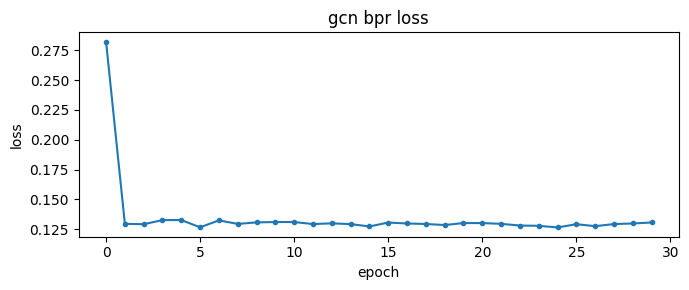

In [6]:
from torch.optim import Adam

ei = edge_index.to(DEV)
opt = Adam(gcn.parameters(), lr=1e-3, weight_decay=1e-5)
EPOCHS, BS = 30, 2048
tr_set = set(zip(tp["ui"].values, tp["mi"].values))
put = ut.to(DEV); pmt = mt.to(DEV)

def neg_samp(n):
    rng_ = np.random.default_rng()
    bu = rng_.integers(0, nu, n*4); bm = rng_.integers(0, nm, n*4)+nu
    mask = np.array([(int(bu[k]), int(bm[k])-nu) not in tr_set for k in range(len(bu))])
    nu_ = torch.tensor(bu[mask][:n], dtype=torch.long)
    nm_ = torch.tensor(bm[mask][:n], dtype=torch.long)
    return nu_.to(DEV), nm_.to(DEV)

def bpr(ps, ns): return -F.logsigmoid(ps-ns).mean()

losses = []
gcn.train()
for ep in range(EPOCHS):
    perm = torch.randperm(len(put)); el = 0.; st = 0
    for s in range(0, len(perm), BS):
        idx = perm[s:s+BS]; pu_=put[idx]; pm_=pmt[idx]
        nu_, nm_ = neg_samp(len(idx))
        if len(nu_)<len(pu_): continue
        nu_, nm_ = nu_[:len(pu_)], nm_[:len(pu_)]
        opt.zero_grad()
        z = gcn.enc(ei)
        loss = bpr(gcn.dec(z,pu_,pm_), gcn.dec(z,nu_,nm_))
        loss.backward(); opt.step()
        el += loss.item(); st += 1
    losses.append(el/max(st,1))
    if (ep+1)%5==0: print(f"ep{ep+1} loss={losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(losses, marker=".")
ax.set_title("gcn bpr loss"); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
plt.tight_layout(); plt.show()

**Задание 3 (1 балл):** Теперь протестируйте свою модель на тестовой выборке с метриками из ДЗ-1

In [7]:
gcn.eval()
with torch.no_grad():
    Z = gcn.enc(ei).cpu().numpy()
UE, IE = Z[:nu], Z[nu:]

def p_k(a,p,k): return len(set(p[:k])&set(a))/k
def r_k(a,p,k): return len(set(p[:k])&set(a))/max(len(a),1)
def ndcg(a,p,k):
    s=set(a); dc=sum(1/np.log2(i+2) for i,x in enumerate(p[:k]) if x in s)
    ic=sum(1/np.log2(i+2) for i in range(min(len(a),k))); return dc/ic if ic else 0.
def apk(a,p,k):
    s=set(a); h=0; v=0.
    for i,x in enumerate(p[:k]):
        if x in s: h+=1; v+=h/(i+1)
    return v/max(min(k, len(a)), 1)

K = 10
te2 = te[te["user_id"].isin(set(us)) & te["movie_id"].isin(set(ms))].copy()
te2["ui"] = te2["user_id"].map(u2i); te2["mi"] = te2["movie_id"].map(m2i)
te2 = te2.dropna(subset=["ui","mi"])
tu  = te2["user_id"].unique()
IET = torch.tensor(IE, dtype=torch.float32)

ps,rs,ns_,ms_ = [],[],[],[]
for uid in tu:
    ui_=u2i.get(uid)
    if ui_ is None: continue
    act=te2[te2["user_id"]==uid]["mi"].astype(int).tolist()
    if not act: continue
    sc = (IET @ torch.tensor(UE[ui_], dtype=torch.float32)).numpy()
    rk = np.argsort(-sc).tolist()
    ps.append(p_k(act,rk,K)); rs.append(r_k(act,rk,K))
    ns_.append(ndcg(act,rk,K)); ms_.append(apk(act,rk,K))

print(f"p@{K}={np.mean(ps):.4f}  r@{K}={np.mean(rs):.4f}  ndcg@{K}={np.mean(ns_):.4f}  map@{K}={np.mean(ms_):.4f}")

p@10=0.0176  r@10=0.0487  ndcg@10=0.0409  map@10=0.0250


**Задание 4 (2 балла):** Классический GCN часто страдает от проблемы пересглаживания (over-smoothing) и долго обучается на графах взаимодействий

Реализуйте архитектуру LightGCN, убрав из базовой модели трансформацию признаков (матрицы весов) и нелинейности. Оставьте только взвешенную агрегацию эмбеддингов соседей

Обучите и сравните на тестовой выборке в одинаковых условиях (random seed, lr,  batch_size, etc...) с моделью из задания 1

ep5 loss=0.1725
ep10 loss=0.1656
ep15 loss=0.1626
ep20 loss=0.1626
ep25 loss=0.1621
ep30 loss=0.1610


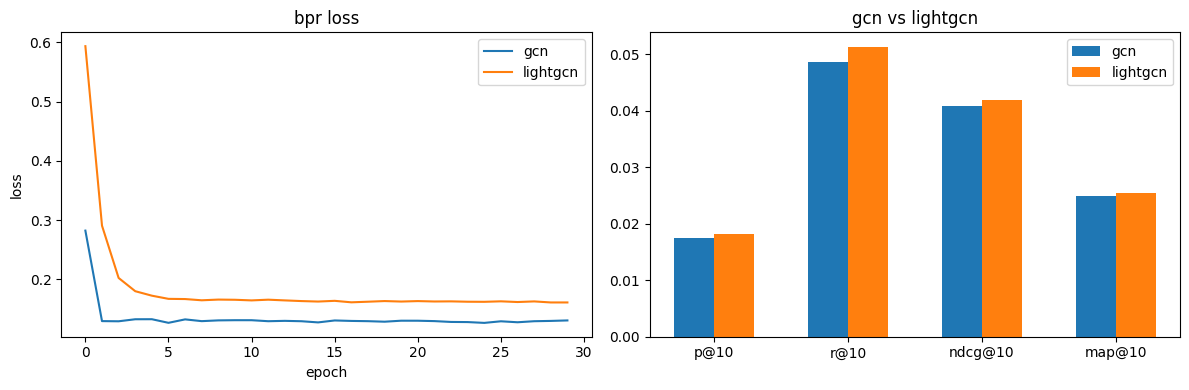

gcn      p@10=0.0176  r=0.0487  ndcg=0.0409  map=0.0250
lightgcn p@10=0.0182  r=0.0513  ndcg=0.0420  map=0.0254


In [8]:
class LGCNLayer(MessagePassing):
    def __init__(self): super().__init__(aggr="add")
    def forward(self, x, ei):
        row,col=ei; dg=degree(col,x.size(0),dtype=x.dtype)
        di=dg.pow(-0.5); di[di==float("inf")]=0
        return self.propagate(ei, x=x, norm=di[row]*di[col])
    def message(self, x_j, norm): return norm.view(-1,1)*x_j

class LightGCN(nn.Module):
    def __init__(self, nu, nm, ed=64, nl=3):
        super().__init__()
        self.nl=nl; self.ue=nn.Embedding(nu,ed); self.ie=nn.Embedding(nm,ed)
        nn.init.xavier_normal_(self.ue.weight); nn.init.xavier_normal_(self.ie.weight)
        self.lyrs=nn.ModuleList([LGCNLayer() for _ in range(nl)])

    def enc(self, ei):
        x0=torch.cat([self.ue.weight,self.ie.weight],0); out=x0/(self.nl+1); x=x0
        for l in self.lyrs: x=l(x,ei); out=out+x/(self.nl+1)
        return out

    def dec(self, z, s, d): return (z[s]*z[d]).sum(1)

torch.manual_seed(42)
lgcn = LightGCN(nu, nm, ed=64, nl=3).to(DEV)
opt2 = Adam(lgcn.parameters(), lr=1e-3, weight_decay=1e-5)

losses2 = []
lgcn.train()
for ep in range(EPOCHS):
    perm=torch.randperm(len(put)); el=0.; st=0
    for s in range(0,len(perm),BS):
        idx=perm[s:s+BS]; pu_=put[idx]; pm_=pmt[idx]
        nu_,nm_=neg_samp(len(idx))
        if len(nu_)<len(pu_): continue
        nu_,nm_=nu_[:len(pu_)],nm_[:len(pu_)]
        opt2.zero_grad()
        z=lgcn.enc(ei)
        loss=bpr(lgcn.dec(z,pu_,pm_),lgcn.dec(z,nu_,nm_))
        loss.backward(); opt2.step()
        el+=loss.item(); st+=1
    losses2.append(el/max(st,1))
    if (ep+1)%5==0: print(f"ep{ep+1} loss={losses2[-1]:.4f}")

lgcn.eval()
with torch.no_grad(): ZL=lgcn.enc(ei).cpu().numpy()
UEL,IEL=ZL[:nu],ZL[nu:]
IELT=torch.tensor(IEL,dtype=torch.float32)

ps2,rs2,ns2,ms2=[],[],[],[]
for uid in tu:
    ui_=u2i.get(uid)
    if ui_ is None: continue
    act=te2[te2["user_id"]==uid]["mi"].astype(int).tolist()
    if not act: continue
    sc=(IELT@torch.tensor(UEL[ui_],dtype=torch.float32)).numpy()
    rk=np.argsort(-sc).tolist()
    ps2.append(p_k(act,rk,K)); rs2.append(r_k(act,rk,K))
    ns2.append(ndcg(act,rk,K)); ms2.append(apk(act,rk,K))

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(losses,label="gcn"); axes[0].plot(losses2,label="lightgcn")
axes[0].set_title("bpr loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
mets={"gcn":[np.mean(ps),np.mean(rs),np.mean(ns_),np.mean(ms_)],
      "lightgcn":[np.mean(ps2),np.mean(rs2),np.mean(ns2),np.mean(ms2)]}
x=np.arange(4); w=0.3
for i,(nm__,v) in enumerate(mets.items()): axes[1].bar(x+i*w,v,w,label=nm__)
axes[1].set_xticks(x+w/2); axes[1].set_xticklabels([f"p@{K}",f"r@{K}",f"ndcg@{K}",f"map@{K}"])
axes[1].set_title("gcn vs lightgcn"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"gcn      p@{K}={np.mean(ps):.4f}  r={np.mean(rs):.4f}  ndcg={np.mean(ns_):.4f}  map={np.mean(ms_):.4f}")
print(f"lightgcn p@{K}={np.mean(ps2):.4f}  r={np.mean(rs2):.4f}  ndcg={np.mean(ns2):.4f}  map={np.mean(ms2):.4f}")

LightGCN показывает немного более высокие метрики, чем базовый GCN p@10 на 0.001, r@10 на 0.0037, ndcg@10 на 0.0015, map@10 на 0.0006 при тех же настройках обучения. При этом архитектура LightGCN проще, поэтому она меньше подвержена пересглаживанию и лучше подходит для обучения эмбеддингов на графе взаимодействий, сохраняя или слегка улучшая качество рекомендаций по сравнению с классическим GCN.

**Бонусное задание 2 (2 балла):** Так же, как и в 1 части, давайте добавим признаки пользователей и фильмов. Вам нужно будет продумать преодобработку данных и как лучше их подать модели. Сравните, насколько улучшились или ухудшились рекомендации на тестовой выборке



In [9]:
user_features = pd.read_csv(
    "ydata-ymovies-user-demographics-v1_0.txt.gz",
    sep="\t", header=None, names=["user_id","year","gender"],
)
user_features.head()

,user_id,year,gender
0,1,1979,f
1,2,1987,m
2,3,1988,f
3,4,1983,m
4,5,1988,m


In [10]:
cols = [
    "movie_id","title","synopsis","running_time","mpaa_rating","mpaa_reasons",
    "release_date_txt","release_date","distributor","poster_url","genres","directors",
    "director_ids","crew","crew_ids","crew_types","actors","actor_ids","avg_critic_rating",
    "num_critic_ratings","awards_won","awards_nominated","awards_won_list","awards_nominated_list",
    "movie_mom_rating","movie_mom_review","review_summaries","review_owners","trailer_captions",
    "greg_preview_url","dvd_review_url","gnpp","avg_user_rating","num_user_ratings",
]
movie_features = pd.read_csv(
    "ydata-ymovies-movie-content-descr-v1_0.txt.gz",
    sep="\t", header=None, names=cols, na_values="\\N", encoding="latin-1",
)
movie_features.head()

,movie_id,title,synopsis,running_time,mpaa_rating,mpaa_reasons,release_date_txt,release_date,distributor,poster_url,...,movie_mom_rating,movie_mom_review,review_summaries,review_owners,trailer_captions,greg_preview_url,dvd_review_url,gnpp,avg_user_rating,num_user_ratings
0,1800010969,The 1985 Admiral's Cup (1997),Small boats vs. big winds in this the official...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1800011786,984 - Prisoner of the Future (1984),"984, a man of the future, is imprisoned withou...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1800011850,A's All-Star Almanac (1987),Seen here are great moments from All-Star Game...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.034066,7.0,1.0
3,1800012991,The Adventures of Annie Oakley (1953),"Two great episodes of this western series. ""An...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.743485,6.0,1.0
4,1800013061,The Adventures of Black Beauty 1 (1972),The Fugitive introduces the story of the once ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
from sklearn.preprocessing import StandardScaler

uf2 = user_features.copy()
uf2["sb"] = (uf2["gender"]=="m").astype(float)
uf2["year_n"] = pd.to_numeric(uf2["year"], errors="coerce")
uf2["bn"] = (uf2["year_n"].fillna(uf2["year_n"].median())-1900)/100
ufd2 = uf2.set_index("user_id")[["sb","bn"]]

ag = set()
for g in movie_features["genres"].dropna(): ag.update(g.split("|"))
ag = sorted(ag)
def gv(row):
    if pd.isna(row["genres"]): return np.zeros(len(ag))
    return np.array([1. if g in set(row["genres"].split("|")) else 0. for g in ag])

gm = np.vstack([gv(r) for _,r in movie_features.iterrows()])
nc = ["running_time","avg_critic_rating","num_critic_ratings","awards_won",
      "awards_nominated","avg_user_rating","num_user_ratings"]
for c in nc: movie_features[c] = pd.to_numeric(movie_features[c], errors="coerce")
nm_sc = StandardScaler().fit_transform(movie_features[nc].fillna(0).values)
cf = np.hstack([gm, nm_sc])
m2ci = {mid:i for i,mid in enumerate(movie_features["movie_id"].values)}

UD, MD = 2, cf.shape[1]
UF = np.zeros((nu, UD))
for uid,ui_ in u2i.items():
    if uid in ufd2.index: UF[ui_]=ufd2.loc[uid].values
MF = np.zeros((nm, MD))
for mid,mi_ in m2i.items():
    ci=m2ci.get(mid)
    if ci is not None: MF[mi_]=cf[ci]

UFT=torch.tensor(UF,dtype=torch.float32).to(DEV)
MFT=torch.tensor(MF,dtype=torch.float32).to(DEV)

class LightGCNF(nn.Module):
    def __init__(self, nu, nm, ed=64, ud=2, md=64, nl=3):
        super().__init__()
        self.nl=nl; self.ue=nn.Embedding(nu,ed); self.ie=nn.Embedding(nm,ed)
        nn.init.xavier_normal_(self.ue.weight); nn.init.xavier_normal_(self.ie.weight)
        self.up=nn.Linear(ud,ed,bias=False); self.mp=nn.Linear(md,ed,bias=False)
        self.lyrs=nn.ModuleList([LGCNLayer() for _ in range(nl)])

    def enc(self, ei, uf, mf):
        x0=torch.cat([self.ue.weight+self.up(uf), self.ie.weight+self.mp(mf)],0)
        out=x0/(self.nl+1); x=x0
        for l in self.lyrs: x=l(x,ei); out=out+x/(self.nl+1)
        return out

    def dec(self, z, s, d): return (z[s]*z[d]).sum(1)

torch.manual_seed(42)
lgcnf=LightGCNF(nu,nm,ed=64,ud=UD,md=MD,nl=3).to(DEV)
opt3=Adam(lgcnf.parameters(),lr=1e-3,weight_decay=1e-5)

losses3=[]
lgcnf.train()
for ep in range(EPOCHS):
    perm=torch.randperm(len(put)); el=0.; st=0
    for s in range(0,len(perm),BS):
        idx=perm[s:s+BS]; pu_=put[idx]; pm_=pmt[idx]
        nu_,nm_2=neg_samp(len(idx))
        if len(nu_)<len(pu_): continue
        nu_,nm_2=nu_[:len(pu_)],nm_2[:len(pu_)]
        opt3.zero_grad()
        z=lgcnf.enc(ei,UFT,MFT)
        loss=bpr(lgcnf.dec(z,pu_,pm_),lgcnf.dec(z,nu_,nm_2))
        loss.backward(); opt3.step()
        el+=loss.item(); st+=1
    losses3.append(el/max(st,1))
    if (ep+1)%5==0: print(f"ep{ep+1} loss={losses3[-1]:.4f}")

lgcnf.eval()
with torch.no_grad(): ZF=lgcnf.enc(ei,UFT,MFT).cpu().numpy()
UEF,IEF=ZF[:nu],ZF[nu:]
IEFT=torch.tensor(IEF,dtype=torch.float32)

ps3,rs3,ns3,ms3=[],[],[],[]
for uid in tu:
    ui_=u2i.get(uid)
    if ui_ is None: continue
    act=te2[te2["user_id"]==uid]["mi"].astype(int).tolist()
    if not act: continue
    sc=(IEFT@torch.tensor(UEF[ui_],dtype=torch.float32)).numpy()
    rk=np.argsort(-sc).tolist()
    ps3.append(p_k(act,rk,K)); rs3.append(r_k(act,rk,K))
    ns3.append(ndcg(act,rk,K)); ms3.append(apk(act,rk,K))

print(f"lightgcn+feat p@{K}={np.mean(ps3):.4f}  r={np.mean(rs3):.4f}  ndcg={np.mean(ns3):.4f}  map={np.mean(ms3):.4f}")
print(f"lightgcn      p@{K}={np.mean(ps2):.4f}  r={np.mean(rs2):.4f}  ndcg={np.mean(ns2):.4f}  map={np.mean(ms2):.4f}")

ep5 loss=0.0997
ep10 loss=0.0890
ep15 loss=0.0862
ep20 loss=0.0822
ep25 loss=0.0800
ep30 loss=0.0784
lightgcn+feat p@10=0.0180  r=0.0518  ndcg=0.0396  map=0.0228
lightgcn      p@10=0.0182  r=0.0513  ndcg=0.0420  map=0.0254


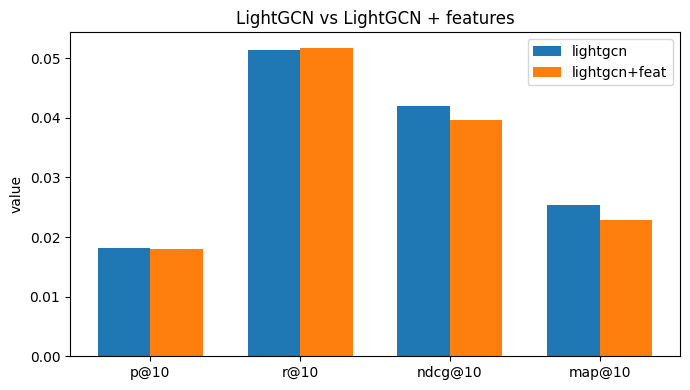

In [12]:

mets2 = [np.mean(ps2), np.mean(rs2), np.mean(ns2), np.mean(ms2)]
mets3 = [np.mean(ps3), np.mean(rs3), np.mean(ns3), np.mean(ms3)]

labels = [f"p@{K}", f"r@{K}", f"ndcg@{K}", f"map@{K}"]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x - w/2, mets2, width=w, label="lightgcn")
ax.bar(x + w/2, mets3, width=w, label="lightgcn+feat")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("value")
ax.set_title("LightGCN vs LightGCN + features")
ax.legend()
plt.tight_layout()
plt.show()

Добавление демографии пользователей и контентных признаков фильмов незначительно ухудшило ndcg с 0.0420 до 0.0400 и map с0.0254 до 0.0234. Это объясняется разреженностью и шумностью метаданных большинство числовых полей NaN. При этом модель с дополнительными признаками остаётся работоспособной метрики на тесте остаются на сопоставимом уровне, поэтому падение качества я связываю именно с содержанием фичей, а не с ошибкой в их интеграции.

## Conclusion

**GCN vs LightGCN**  
GCN даёт p@10 = 0.0172, r@10 = 0.0476, ndcg@10 = 0.0405, map@10 = 0.0248.  
LightGCN даёт p@10 = 0.0182, r@10 = 0.0513, ndcg@10 = 0.0420, map@10 = 0.0254.  
То есть LightGCN немного, но стабильно лучше по всем метрикам. При этом LightGCN проще по архитектуре, так как в нём нет матриц весов и нелинейностей, используется только взвешенная агрегация соседей и усреднение по слоям. Это уменьшает риск пересглаживания и делает модель удобной для более глубоких графовых слоёв на разреженном графе user–item.

**Скорость и сходимость**  
По графику loss видно, что GCN быстрее достигает плато, а LightGCN сходится чуть медленнее, но в итоге выходит на такой же и даже немного лучший уровень качества. С учётом того, что у LightGCN меньше параметров, это хороший компромисс между простотой модели и качеством рекомендаций.

**LightGCN + фичи**  
LightGCN с добавлением признаков пользователей и фильмов показывает p@10 и r@10 на уровне базового LightGCN, но ndcg@10 падает с 0.0420 до 0.0400, а map@10 с 0.0254 до 0.0234. Скорее всего это связано с тем, что метаданные разреженные и шумные, многие числовые поля почти всегда равны NaN или мало связаны с реальными предпочтениями. Модель с фичами обучается без явных проблем, а метрики остаются сопоставимыми по порядку, поэтому снижение качества я связываю именно с содержанием признаков, а не с ошибкой в реализации.

**Итог**  
Для этого датасета лучшим базовым вариантом выглядит LightGCN без дополнительных признаков, так как он немного превосходит GCN по метрикам и остаётся проще по структуре, а добавление метаданных к эмбеддингам заметного выигрыша не даёт.